<a href="https://colab.research.google.com/github/shailjagupta928-ui/machine-learning-project/blob/main/Walmart_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

In [ ]:
df = pd.read_csv("Walmart DataSet.csv")

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
df.isnull().mean()

,0
Store,0.0
Date,0.0
Weekly_Sales,0.0
Holiday_Flag,0.0
Temperature,0.0
Fuel_Price,0.0
CPI,0.0
Unemployment,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)

In [ ]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday

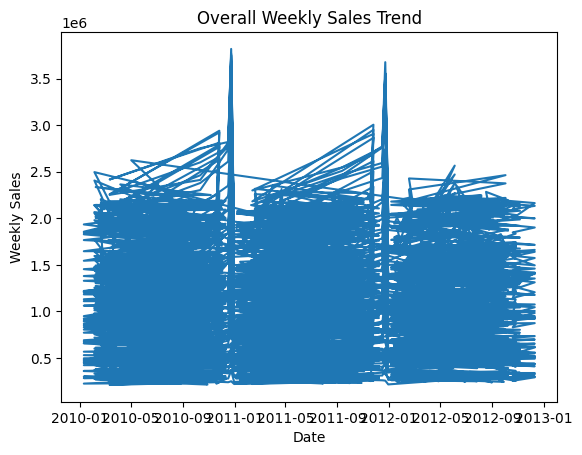

In [ ]:
plt.figure()
plt.plot(df['Date'],
df['Weekly_Sales'])
plt.title('Overall Weekly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

year wise sale analysis

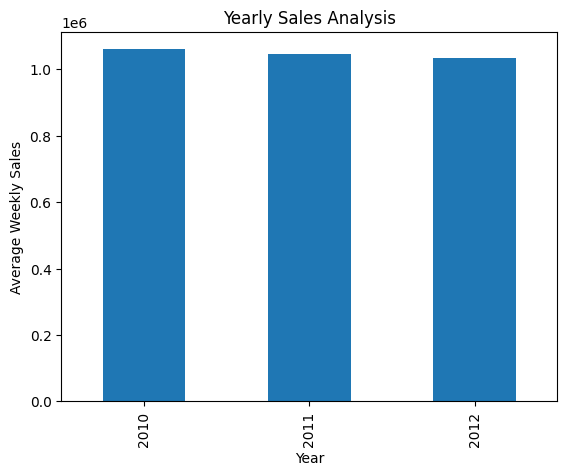

In [ ]:
yearly_sales = df.groupby('year')['Weekly_Sales'].mean()
plt.figure()
yearly_sales.plot(kind='bar')
plt.title('Yearly Sales Analysis')
plt.xlabel('Year')
plt.ylabel('Average Weekly Sales')
plt.show()

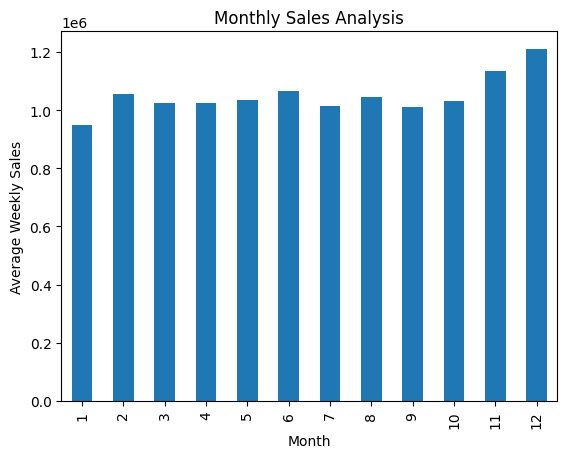

In [ ]:
monthly_sales = df.groupby('month')['Weekly_Sales'].mean()
plt.figure()
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.show()

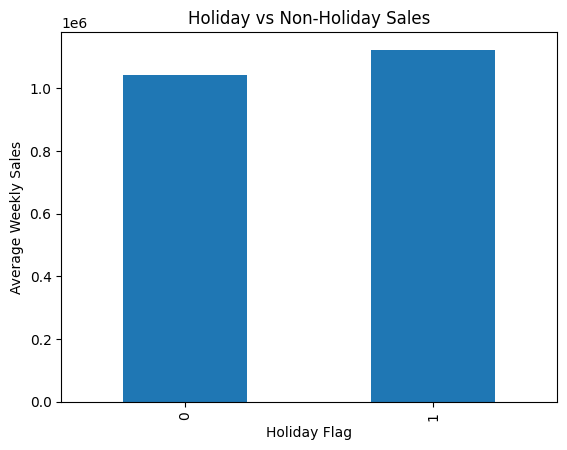

In [ ]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.figure()
holiday_sales.plot(kind='bar')
plt.title('Holiday vs Non-Holiday Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Weekly Sales')
plt.show()


<Figure size 640x480 with 0 Axes>

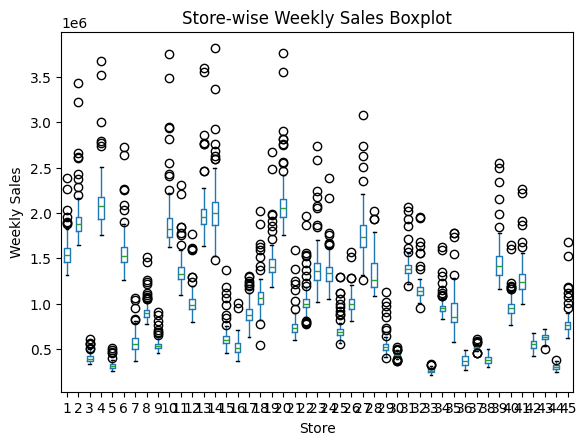

In [ ]:
plt.figure()
df.boxplot(column='Weekly_Sales', by='Store', grid=False)
plt.title("Store-wise Weekly Sales Boxplot")
plt.suptitle("")
plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.show()

In [ ]:
corr = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()



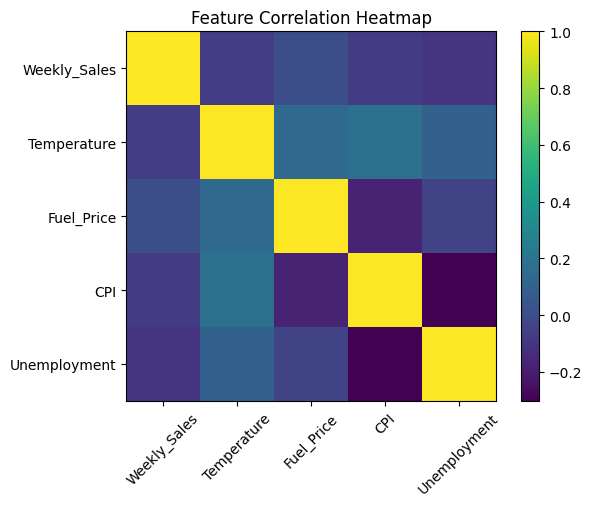

In [ ]:
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)),
corr.columns, rotation=45)
plt.yticks(range(len(corr)),
corr.columns)
plt.title("Feature Correlation Heatmap")
plt.show()

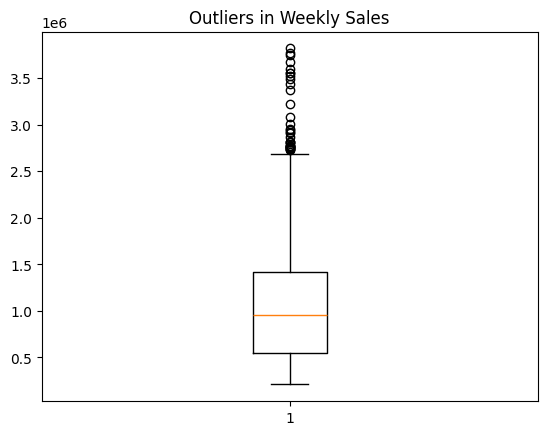

In [ ]:
plt.figure()
plt.boxplot(df['Weekly_Sales'])
plt.title("Outliers in Weekly Sales")
plt.show()

Feature Engineering

In [ ]:
df['lag_1'] = df["Weekly_Sales"].shift(1)
df['lag_7'] = df["Weekly_Sales"].shift(7)
df['lag_14'] = df["Weekly_Sales"].shift(14)

In [ ]:
df['rolling_7'] = df["Weekly_Sales"].rolling(7).mean()
df['rolling_14'] = df["Weekly_Sales"].rolling(14).mean()

In [ ]:
df['holiday_sales_effect'] = df['Holiday_Flag'] * df['Weekly_Sales']

In [ ]:
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

In [ ]:
df.dropna(inplace=True)

In [ ]:
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

X_train = train.drop(['Date', 'Weekly_Sales'], axis=1)
y_train = train['Weekly_Sales']
X_test = test.drop(['Date', 'Weekly_Sales'], axis=1)
y_test = test['Weekly_Sales']

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(mean_absolute_error(y_test, lr_pred))
print(mean_squared_error(y_test, lr_pred))


84392.03546283249
13228025563.125702


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=None,random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 47016.83303547805
Mean Squared Error: 5015893421.335729


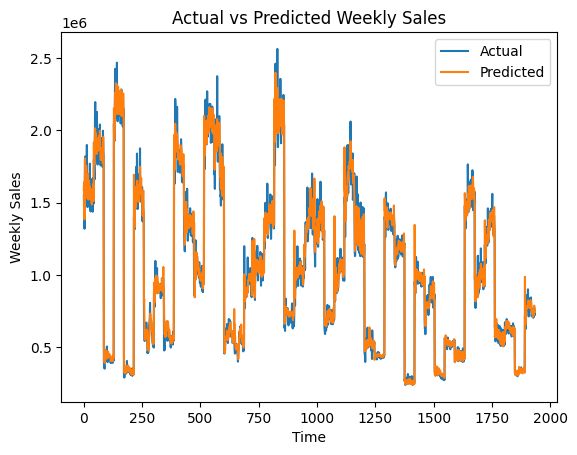

In [ ]:
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Weekly Sales')
plt.xlabel('Time')
plt.ylabel('Weekly Sales')
plt.show()

Text(0.5, 1.0, 'Feature Importance')

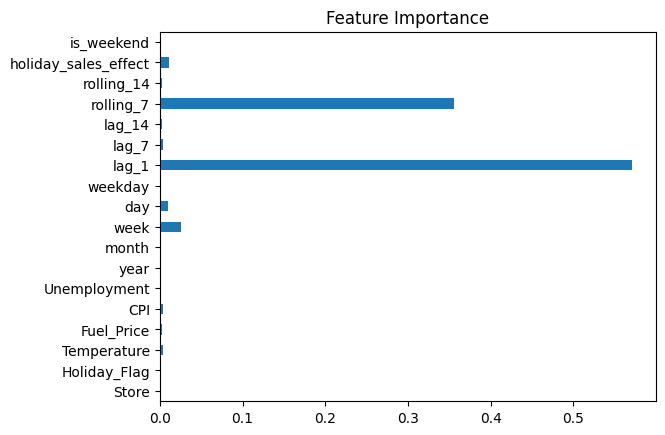

In [ ]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False)
plt.figure()
importance.plot(kind='barh')
plt.title('Feature Importance')

In [ ]:
pipeline = Pipeline(steps=[('scaler', StandardScaler()),
                           ('model', RandomForestRegressor(n_estimators=200,random_state=42))])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
future_sales = pipeline.predict(X_test.tail(30))

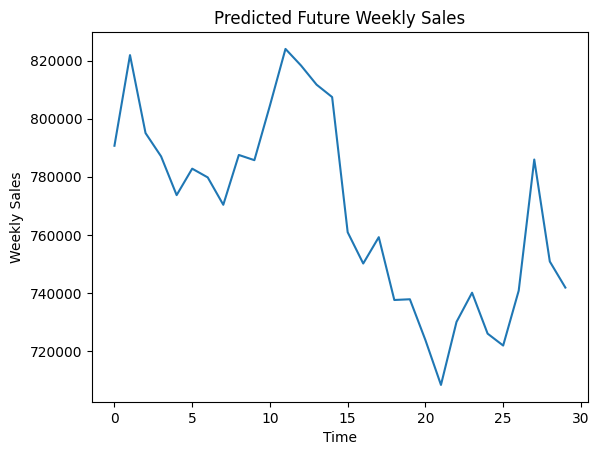

In [ ]:
plt.figure()
plt.plot(future_sales)
plt.title('Predicted Future Weekly Sales')
plt.xlabel('Time')
plt.ylabel('Weekly Sales')
plt.show()

In [ ]:
import pickle
pickle.dump(pipeline, open('model.pkl', 'wb'))

In [ ]:
with open('sales_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)